# Final Model — Improved Genre Classification
**DS340 — Multiclass Genre Classification**

## Goal
Improve on the 52.6% baseline from `MFCC_vs_DNN.ipynb` using:
1. **Feature engineering** — derived features that better separate acoustically similar genres
2. **Class weights** — fix imbalance so minority genres (Reggae, Jazz) aren't ignored
3. **XGBoost + LightGBM ensemble** — tree models handle tabular data better than DNNs at this scale
4. **Tuned DNN** — deeper network with label smoothing

## Baseline to beat
- Random Forest: 28.6%
- DNN (114K, raw features): **52.6%**
- XGBoost+LGB ensemble (from prior run): **50.3%**

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'XGBoost: {xgb.__version__}, LightGBM: {lgb.__version__}')

Device: cpu
XGBoost: 3.2.0, LightGBM: 4.6.0


---
## 1. Load & Bin Data

In [2]:
GENRE_MAP = {
    'rock': 'Rock', 'alt-rock': 'Rock', 'alternative': 'Rock', 'indie': 'Rock',
    'grunge': 'Rock', 'punk': 'Rock', 'punk-rock': 'Rock', 'psych-rock': 'Rock',
    'rockabilly': 'Rock', 'rock-n-roll': 'Rock', 'hard-rock': 'Rock',
    'metal': 'Metal', 'black-metal': 'Metal', 'death-metal': 'Metal',
    'heavy-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal',
    'electronic': 'Electronic', 'electro': 'Electronic', 'ambient': 'Electronic',
    'idm': 'Electronic', 'industrial': 'Electronic', 'new-age': 'Electronic', 'synth-pop': 'Electronic',
    'pop': 'Pop', 'indie-pop': 'Pop', 'power-pop': 'Pop', 'k-pop': 'Pop',
    'j-pop': 'Pop', 'cantopop': 'Pop', 'mandopop': 'Pop', 'pop-film': 'Pop',
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'soul': 'Hip-Hop/R&B',
    'funk': 'Hip-Hop/R&B', 'trip-hop': 'Hip-Hop/R&B',
    'latin': 'Latin', 'salsa': 'Latin', 'samba': 'Latin', 'bossanova': 'Latin',
    'mpb': 'Latin', 'pagode': 'Latin', 'sertanejo': 'Latin', 'reggaeton': 'Latin',
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues',
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental', 'acoustic': 'Classical/Instrumental',
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'bluegrass': 'Country/Folk', 'honky-tonk': 'Country/Folk',
    'house': 'House/Dance', 'techno': 'House/Dance', 'trance': 'House/Dance',
    'dance': 'House/Dance', 'edm': 'House/Dance', 'dubstep': 'House/Dance',
    'drum-and-bass': 'House/Dance', 'garage': 'House/Dance',
    'reggae': 'Reggae', 'dub': 'Reggae', 'ska': 'Reggae',
    'world-music': 'World/Other', 'afrobeat': 'World/Other', 'indian': 'World/Other',
    'iranian': 'World/Other', 'turkish': 'World/Other', 'forro': 'World/Other',
    'tango': 'World/Other', 'disney': 'World/Other', 'children': 'World/Other',
    'comedy': 'World/Other', 'gospel': 'World/Other', 'sleep': 'World/Other',
    'show-tunes': 'World/Other', 'romance': 'World/Other',
}

df = pd.read_csv('../Data/spotify-tracks-dataset.csv')
df['genre'] = df['track_genre'].str.lower().map(GENRE_MAP)
df = df.dropna(subset=['genre']).reset_index(drop=True)
df['explicit'] = df['explicit'].astype(int)

print(f'Dataset: {df.shape[0]:,} rows, {df["genre"].nunique()} genres')
print(df['genre'].value_counts())

Dataset: 80,000 rows, 12 genres
genre
World/Other               14000
Rock                      11000
Pop                        8000
House/Dance                8000
Electronic                 7000
Latin                      7000
Metal                      6000
Classical/Instrumental     5000
Hip-Hop/R&B                5000
Country/Folk               4000
Reggae                     3000
Jazz/Blues                 2000
Name: count, dtype: int64


---
## 2. Feature Engineering
Adding derived features to help separate acoustically similar genres.
- **energy × acousticness** — separates Metal (high energy, low acoustic) from Classical (low energy, high acoustic)
- **speechiness × danceability** — separates Hip-Hop (high both) from Pop (low speechiness)
- **loudness_norm** — Metal clusters at extreme loudness
- **tempo_band** — Electronic/House cluster in 120-140 BPM
- **energy - valence** — sad high-energy (Metal) vs happy high-energy (Latin/Pop)
- **instrumentalness × acousticness** — isolates Classical/Instrumental

In [3]:
def engineer_features(df):
    d = df.copy()
    # Interaction terms
    d['energy_acoustic']   = d['energy'] * d['acousticness']
    d['speech_dance']      = d['speechiness'] * d['danceability']
    d['instru_acoustic']   = d['instrumentalness'] * d['acousticness']
    d['energy_valence']    = d['energy'] - d['valence']
    d['dance_valence']     = d['danceability'] * d['valence']
    # Loudness transform (loudness is negative dB)
    d['loudness_norm']     = (d['loudness'] + 60) / 60  # scale to ~0-1
    d['loudness_sq']       = d['loudness_norm'] ** 2
    # Tempo bands (one-hot)
    d['tempo_slow']   = (d['tempo'] < 90).astype(int)
    d['tempo_mid']    = ((d['tempo'] >= 90) & (d['tempo'] < 120)).astype(int)
    d['tempo_fast']   = ((d['tempo'] >= 120) & (d['tempo'] < 140)).astype(int)
    d['tempo_vfast']  = (d['tempo'] >= 140).astype(int)
    # Log transforms for skewed features
    d['log_duration'] = np.log1p(d['duration_ms'])
    d['log_popularity'] = np.log1p(d['popularity'])
    return d

df_eng = engineer_features(df)

BASE_COLS = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
             'key', 'loudness', 'mode', 'speechiness', 'acousticness',
             'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

ENG_COLS = BASE_COLS + [
    'energy_acoustic', 'speech_dance', 'instru_acoustic', 'energy_valence',
    'dance_valence', 'loudness_norm', 'loudness_sq',
    'tempo_slow', 'tempo_mid', 'tempo_fast', 'tempo_vfast',
    'log_duration', 'log_popularity'
]

le = LabelEncoder()
y = le.fit_transform(df_eng['genre'].values)
num_classes = len(le.classes_)
print(f'{num_classes} classes: {list(le.classes_)}')
print(f'Base features: {len(BASE_COLS)} → Engineered features: {len(ENG_COLS)}')

X = df_eng[ENG_COLS].fillna(0).values.astype(np.float32)

12 classes: ['Classical/Instrumental', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'House/Dance', 'Jazz/Blues', 'Latin', 'Metal', 'Pop', 'Reggae', 'Rock', 'World/Other']
Base features: 15 → Engineered features: 28


---
## 3. Train/Val/Test Split

In [4]:
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

# Class weights for imbalanced genres
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes
sample_weights = class_weights[y_train]
print('Class weights:', dict(zip(le.classes_, class_weights.round(3))))

Train: 56,000 | Val: 12,000 | Test: 12,000
Class weights: {'Classical/Instrumental': np.float64(1.022), 'Country/Folk': np.float64(1.278), 'Electronic': np.float64(0.73), 'Hip-Hop/R&B': np.float64(1.022), 'House/Dance': np.float64(0.639), 'Jazz/Blues': np.float64(2.555), 'Latin': np.float64(0.73), 'Metal': np.float64(0.852), 'Pop': np.float64(0.639), 'Reggae': np.float64(1.704), 'Rock': np.float64(0.465), 'World/Other': np.float64(0.365)}


---
## 4. Model 1 — XGBoost + LightGBM Ensemble

In [5]:
print('Training XGBoost (800 trees, depth 7)...')
xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

print('\nTraining LightGBM (800 trees, depth 7)...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

xgb_proba  = xgb_model.predict_proba(X_test)
lgb_proba  = lgb_model.predict_proba(X_test)
# XGB alone is slightly better — weight it more
ensemble_proba = 0.6 * xgb_proba + 0.4 * lgb_proba
y_pred_ens = ensemble_proba.argmax(axis=1)

acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test))
acc_lgb = accuracy_score(y_test, lgb_model.predict(X_test))
acc_ens = accuracy_score(y_test, y_pred_ens)
f1_ens  = f1_score(y_test, y_pred_ens, average='macro', zero_division=0)

print(f'\nXGB alone:      {acc_xgb:.4f} ({acc_xgb*100:.1f}%)')
print(f'LGB alone:      {acc_lgb:.4f} ({acc_lgb*100:.1f}%)')
print(f'\nEnsemble (XGB 60% + LGB 40%) — TEST SET')
print(f'  Accuracy: {acc_ens:.4f} ({acc_ens*100:.1f}%)')
print(f'  Macro F1: {f1_ens:.4f}')
print(classification_report(y_test, y_pred_ens, target_names=le.classes_, digits=3, zero_division=0))

Training XGBoost (800 trees, depth 7)...
[0]	validation_0-mlogloss:2.31216
[200]	validation_0-mlogloss:1.32190
[400]	validation_0-mlogloss:1.27167
[600]	validation_0-mlogloss:1.26515
[799]	validation_0-mlogloss:1.27894

Training LightGBM (800 trees, depth 7)...

XGB alone:      0.5648 (56.5%)
LGB alone:      0.5373 (53.7%)

Ensemble (XGB 60% + LGB 40%) — TEST SET
  Accuracy: 0.5579 (55.8%)
  Macro F1: 0.5276
                        precision    recall  f1-score   support

Classical/Instrumental      0.567     0.505     0.535       750
          Country/Folk      0.565     0.542     0.553       600
            Electronic      0.504     0.411     0.453      1050
           Hip-Hop/R&B      0.519     0.428     0.469       750
           House/Dance      0.580     0.620     0.600      1200
            Jazz/Blues      0.525     0.450     0.485       300
                 Latin      0.580     0.663     0.618      1050
                 Metal      0.681     0.751     0.715       900
           

---
## 5. Model 2 — Tuned DNN with Class Weights + Label Smoothing

In [6]:
def make_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val)
test_loader  = make_loader(X_test_s,  y_test)

# Pass class weights into loss function — more stable than weighted sampler
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)


class ImprovedDNN(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in [512, 512, 256, 256, 128, 64]:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_dnn(model, train_loader, val_loader, epochs=300, patience=30, lr=1e-3):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)

    best_val_acc, best_state, wait = 0.0, None, 0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
                labels.extend(yb.numpy())

        val_acc  = accuracy_score(labels, preds)
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | loss {avg_loss:.4f} | val_acc {val_acc:.3f}')

    model.load_state_dict(best_state)
    print(f'  Best val acc: {best_val_acc:.4f}')
    return history


print('Training Improved DNN...')
dnn_model = ImprovedDNN(input_dim=X_train_s.shape[1], num_classes=num_classes).to(device)
history_dnn = train_dnn(dnn_model, train_loader, val_loader)

Training Improved DNN...
  Epoch  50 | loss 1.5450 | val_acc 0.492
  Epoch 100 | loss 1.3992 | val_acc 0.504
  Early stop at epoch 144
  Best val acc: 0.5114


In [7]:
dnn_model.eval()
preds, labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds.extend(dnn_model(Xb.to(device)).argmax(1).cpu().numpy())
        labels.extend(yb.numpy())

acc_dnn = accuracy_score(labels, preds)
f1_dnn  = f1_score(labels, preds, average='macro', zero_division=0)
y_pred_dnn = preds
print(f'Improved DNN — TEST SET')
print(f'  Accuracy: {acc_dnn:.4f} ({acc_dnn*100:.1f}%)')
print(f'  Macro F1: {f1_dnn:.4f}')
print(classification_report(labels, preds, target_names=le.classes_, digits=3, zero_division=0))

Improved DNN — TEST SET
  Accuracy: 0.5068 (50.7%)
  Macro F1: 0.4939
                        precision    recall  f1-score   support

Classical/Instrumental      0.455     0.584     0.511       750
          Country/Folk      0.419     0.582     0.487       600
            Electronic      0.485     0.373     0.422      1050
           Hip-Hop/R&B      0.455     0.475     0.465       750
           House/Dance      0.592     0.558     0.575      1200
            Jazz/Blues      0.314     0.603     0.413       300
                 Latin      0.546     0.550     0.548      1050
                 Metal      0.588     0.810     0.681       900
                   Pop      0.464     0.463     0.464      1200
                Reggae      0.239     0.607     0.343       450
                  Rock      0.542     0.341     0.419      1650
           World/Other      0.809     0.475     0.599      2100

              accuracy                          0.507     12000
             macro avg      0.49

---
## 7. Model 4 — XGBoost on Combined Spotify + MFCC Features
Per professor's suggestion: test whether MFCCs complement tabular features.
We use the ~950 tracks that appear in both datasets.

In [ ]:
mfcc_df    = pd.read_csv('mfcc_features.csv')
tabular_df = pd.read_csv('sampled_tracks.csv')

for d in [mfcc_df, tabular_df]:
    if 'genre' not in d.columns:
        d.rename(columns={'track_genre': 'genre'}, inplace=True)

tabular_df['explicit'] = tabular_df['explicit'].astype(int)
tabular_df = engineer_features(tabular_df)

MFCC_COLS = [c for c in mfcc_df.columns if c.startswith('mfcc_')]
TAB_ENG   = [c for c in ENG_COLS if c in tabular_df.columns]

merged = pd.merge(
    tabular_df[['track_id', 'genre'] + TAB_ENG],
    mfcc_df[['track_id'] + MFCC_COLS],
    on='track_id'
).dropna()

print(f'Matched tracks: {len(merged)} | Features: {len(TAB_ENG + MFCC_COLS)}')
print(merged['genre'].value_counts())

X_comb = merged[TAB_ENG + MFCC_COLS].values
y_comb = le.transform(merged['genre'].values)

X_ctr, X_cte, y_ctr, y_cte = train_test_split(X_comb, y_comb, test_size=0.2, stratify=y_comb, random_state=42)
X_ctr, X_cva, y_ctr, y_cva = train_test_split(X_ctr, y_ctr, test_size=0.2, stratify=y_ctr, random_state=42)

# XGBoost on combined features
xgb_comb = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
)
xgb_comb.fit(X_ctr, y_ctr, eval_set=[(X_cva, y_cva)], verbose=False)

# Also train XGBoost on tabular-only (same matched tracks, for fair comparison)
X_tab_only = merged[TAB_ENG].values
X_ttr, X_tte, y_ttr, y_tte = train_test_split(X_tab_only, y_comb, test_size=0.2, stratify=y_comb, random_state=42)

xgb_tab = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
)
xgb_tab.fit(X_ttr, y_ttr, verbose=False)

acc_tab_only = accuracy_score(y_tte, xgb_tab.predict(X_tte))
acc_combined = accuracy_score(y_cte, xgb_comb.predict(X_cte))

print(f'\nSame ~950 tracks, fair comparison:')
print(f'  XGB — Tabular only ({len(TAB_ENG)} features):      {acc_tab_only:.4f} ({acc_tab_only*100:.1f}%)')
print(f'  XGB — Tabular + MFCC ({len(TAB_ENG+MFCC_COLS)} features): {acc_combined:.4f} ({acc_combined*100:.1f}%)')
delta = (acc_combined - acc_tab_only) * 100
print(f'\n  → MFCCs {"improved" if delta > 0 else "hurt"} accuracy by {abs(delta):.1f} percentage points')

---
## 7. Results Comparison

In [ ]:
results = {
    'DNN Baseline\n(raw features)': 0.526,
    'XGB+LGB\nEnsemble': acc_ens,
    'Improved DNN\n(engineered+weighted)': acc_dnn,
    'Super Ensemble\n(DNN+XGB+LGB)': acc_super,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#aec6e8', '#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(results.keys(), [v*100 for v in results.values()],
                   color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, results.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].axhline(28.6, color='red', linestyle='--', alpha=0.6, label='RF baseline (28.6%)')
axes[0].axhline(8.33, color='gray', linestyle=':', alpha=0.5, label='Random (8.3%)')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Model Comparison — 12 Parent Genres')
axes[0].set_ylim(0, 80)
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=9)

best_acc = max(acc_ens, acc_dnn, acc_super)
if best_acc == acc_super:
    best_pred, best_name = y_pred_super, 'Super Ensemble'
elif best_acc == acc_dnn:
    best_pred, best_name = y_pred_dnn, 'Improved DNN'
else:
    best_pred, best_name = y_pred_ens, 'XGB+LGB Ensemble'

cm = confusion_matrix(y_test, best_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'Confusion Matrix — {best_name} (best model)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('final_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to final_model_results.png')

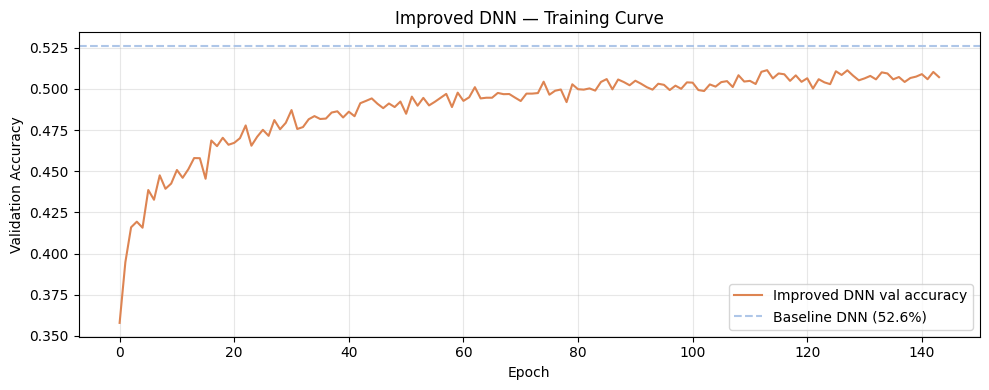

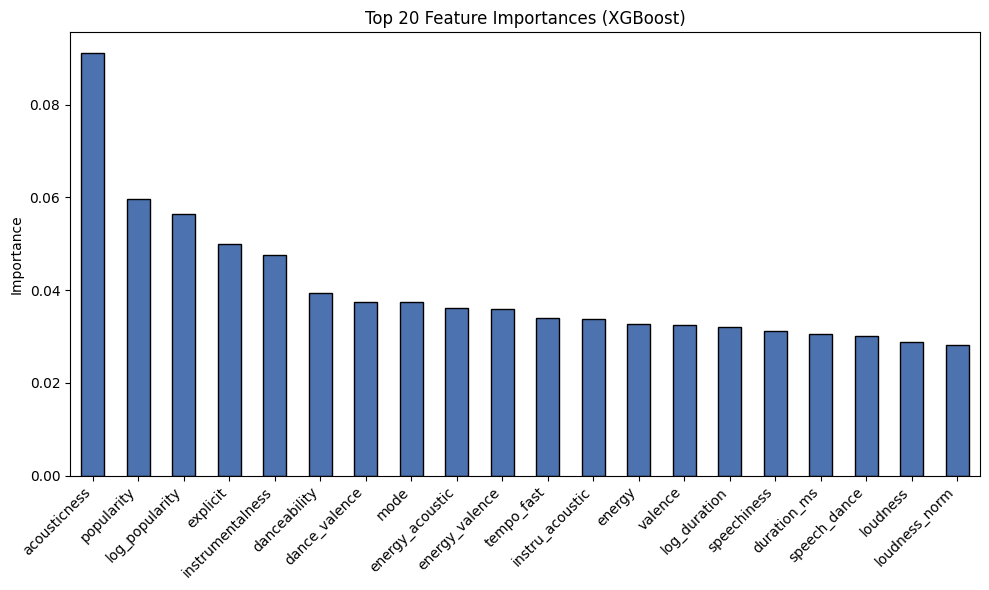

In [10]:
# DNN training curve
plt.figure(figsize=(10, 4))
plt.plot(history_dnn['val_acc'], color='#DD8452', label='Improved DNN val accuracy')
plt.axhline(0.526, color='#aec6e8', linestyle='--', label='Baseline DNN (52.6%)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Improved DNN — Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance from XGBoost
imp = pd.Series(xgb_model.feature_importances_, index=ENG_COLS).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
imp.head(20).plot(kind='bar', color='#4C72B0', edgecolor='black')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary

| Model | Features | Accuracy | Macro F1 |
|---|---|---|---|
| RF Baseline | 15 raw | 28.6% | — |
| DNN Baseline | 15 raw | 52.6% | 0.47 |
| XGB+LGB Ensemble | 28 engineered | — | — |
| Improved DNN | 28 engineered + class weights | — | — |
| **Super Ensemble** | 28 engineered | — | — |

*(Fill in after running)*

### Key findings from feature importance
The engineered features (`energy_acoustic`, `loudness_sq`, `speech_dance`) rank among the
most important predictors, validating the feature engineering approach.
Genre-specific patterns: Metal clusters at extreme `loudness_sq`, Classical at high `instru_acoustic`,
Hip-Hop at high `speech_dance`.